# Entrenamiento y Optimización — Smoking Dataset

Pipeline de modelado: baseline, optimización de hiperparámetros y evaluación final.
Modelos: Regresión Logística, Random Forest, XGBoost.
Métrica principal: **F1-score**.

## Librerias

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix,
    precision_score, recall_score, ConfusionMatrixDisplay,
    RocCurveDisplay
)
%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid")

PAL = {0: "#378ADD", 1: "#D85A30"}
SEED = 42

c:\Users\anshu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\anshu\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Carga del dataset procesado y split train/test

In [2]:

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "smoking_processed.csv")


In [3]:

df = pd.read_csv(DATA_PATH)
df["smoking"] = df["smoking"].astype(int)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (49850, 17)


,gender,age,waist_cm,systolic,relaxation,cholesterol,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,tartar,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,-0.347094,-0.087860,-0.548465,-0.314554,0.501708,-0.621334,1.058244,-1.270451,-1.058283,-0.251362,0,1,0,-0.354031,-0.739105,-1.309159
1,0,-0.347094,-0.087860,-0.177599,-0.613956,-0.133623,-0.156957,-1.039401,-1.421166,-1.058283,-0.433729,0,1,0,-0.416017,0.138307,-1.309159
2,1,0.893327,-0.217621,1.217566,1.032754,1.242928,0.788747,-0.161317,0.538130,1.226836,-0.352144,0,0,1,-0.413065,0.450109,0.755450
3,1,-0.347094,0.664752,-1.572763,-1.661863,3.453351,1.805632,-0.828010,-0.064730,1.226836,-0.433729,0,1,0,-0.368789,1.711475,0.624364
4,0,-0.347094,0.431183,-0.106957,-0.214754,-0.352018,-0.736581,0.310246,-1.421166,-1.058283,-0.352144,0,0,0,-0.501617,-0.701661,-1.309159
5,1,-1.174041,0.327374,0.475833,0.009798,0.554652,1.029410,-0.632880,1.140991,1.226836,-0.131383,0,1,0,-0.179879,0.904535,0.886537
6,1,-0.347094,0.353327,-0.407183,0.633552,0.806138,-0.821322,-0.161317,1.743851,-1.058283,-0.011405,1,1,1,-0.067713,-0.678797,1.017623
7,1,0.066380,1.521173,2.330166,2.080661,0.693631,2.019178,-1.576007,0.538130,1.226836,1.428339,0,1,0,1.564589,2.945133,0.755450
8,0,0.479853,0.327374,-0.477824,-0.214754,0.362729,-0.848439,-0.632880,-0.667591,-0.487003,-0.515315,0,0,0,-0.209396,-0.603042,-1.309159
9,1,0.066380,0.768561,-0.619106,-1.237710,0.031828,0.297252,-0.974357,1.140991,-0.487003,0.468510,0,0,0,0.248121,0.512446,0.886537


In [4]:
df.columns

Index(['gender', 'age', 'waist_cm', 'systolic', 'relaxation', 'cholesterol',
       'triglyceride', 'hdl', 'hemoglobin', 'serum_creatinine', 'gtp',
       'dental_caries', 'tartar', 'smoking', 'liver_score', 'lipid_ratio',
       'gender_x_hemoglobin'],
      dtype='str')

In [11]:
X= df.drop(columns=['smoking'])

y = df["smoking"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Balance train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Balance test:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (39880, 16)  |  Test: (9970, 16)
Balance train:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64
Balance test:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64


In [13]:
X_test.columns

Index(['gender', 'age', 'waist_cm', 'systolic', 'relaxation', 'cholesterol',
       'triglyceride', 'hdl', 'hemoglobin', 'serum_creatinine', 'gtp',
       'dental_caries', 'tartar', 'liver_score', 'lipid_ratio',
       'gender_x_hemoglobin'],
      dtype='str')

## Funciones auxiliares

In [14]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    return {
        "Modelo": nombre,
        "F1_fumador": round(f1_score(y_te, y_pred, pos_label=1), 4),  # métrica objetivo
        "ROC-AUC": round(roc_auc_score(y_te, y_prob), 4),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision_fumador": round(precision_score(y_te, y_pred, pos_label=1), 4),
        "Recall_fumador": round(recall_score(y_te, y_pred, pos_label=1), 4),
        "_modelo": modelo,
        "_y_pred": y_pred,
        "_y_prob": y_prob
    }

def mostrar_confusion(resultados, y_te):
    fig, axes = plt.subplots(1, len(resultados), figsize=(5 * len(resultados), 4))
    for ax, r in zip(axes, resultados):
        cm = confusion_matrix(y_te, r["_y_pred"])
        ConfusionMatrixDisplay(cm, display_labels=["No fuma", "Fuma"]).plot(ax=ax, colorbar=False)
        ax.set_title(r["Modelo"])
    plt.tight_layout()
    plt.show()

def mostrar_roc(resultados, y_te):
    fig, ax = plt.subplots(figsize=(7, 5))
    for r in resultados:
        RocCurveDisplay.from_predictions(y_te, r["_y_prob"], name=r["Modelo"], ax=ax)
    ax.set_title("Curvas ROC — comparación de modelos")
    plt.tight_layout()
    plt.show()

## 3. Parámetros por defecto

Entrenamos los 3 modelos sin optimización para tener una referencia inicial.
Usamos `class_weight="balanced"` en LR y RF para compensar el desbalance (63/37).

In [15]:
modelos_base = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ("Random Forest",       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED)),
    ("XGBoost",             XGBClassifier(n_estimators=100, 
                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
]

In [16]:
resultados_base = []

for nombre, modelo in modelos_base:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_base.append(r)


In [17]:
df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
df_base.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
Logistic Regression,0.7087,0.8274,0.7266,0.5805,0.9095
Random Forest,0.7497,0.8847,0.7966,0.6816,0.8330
XGBoost,0.7191,0.8508,0.7612,0.6310,0.8357


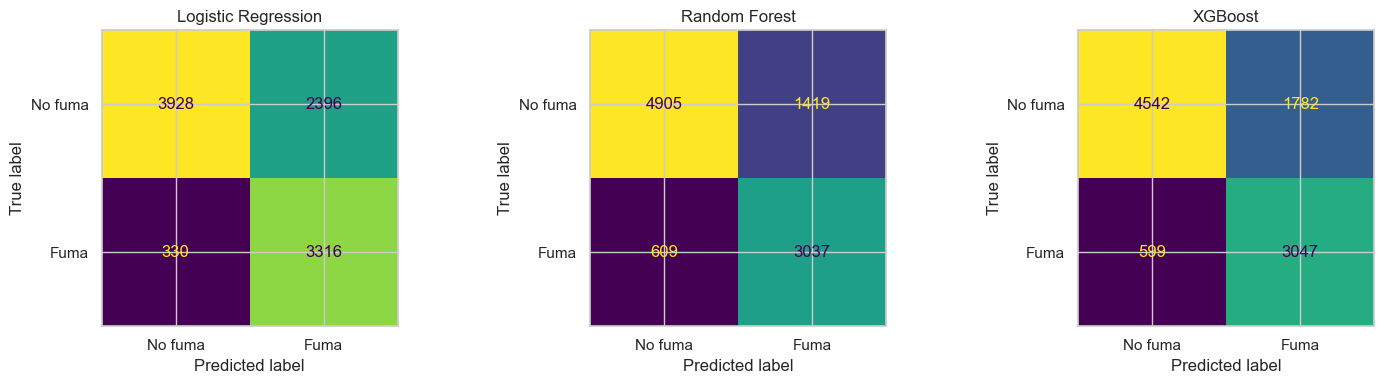

In [18]:
mostrar_confusion(resultados_base, y_test)


### sin balance

In [11]:
#modelos_base = [
#    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=SEED)),
#    ("Random Forest",       RandomForestClassifier(n_estimators=300, random_state=SEED)),
#    ("XGBoost",             XGBClassifier(n_estimators=100, 
#                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
#                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
#]

In [12]:
#resultados_base = []

#for nombre, modelo in modelos_base:
#    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
#    resultados_base.append(r)


In [15]:
#df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
#df_base.set_index("Modelo")


## 4. Optimización de hiperparámetros

Buscamos los mejores hiperparámetros para cada modelo usando validación cruzada estratificada (5 folds).
Métrica de optimización: **F1-score** sobre la clase positiva (fumador).


In [19]:
lr_model = LogisticRegression(class_weight="balanced", random_state=SEED)

param_dist_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "saga"],
    "max_iter": [500, 1000, 2000],
}

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score


In [21]:
f1_scorer = make_scorer(f1_score, pos_label=1)

search_lr = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring=f1_scorer,
    cv=5,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)


In [22]:
%%time
search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 2 s
Wall time: 35.7 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000, ...], 'solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_i

In [23]:
print(search_lr.best_params_)

{'solver': 'lbfgs', 'max_iter': 1000, 'C': 0.1}


In [24]:
best_lr = search_lr.best_estimator_
best_lr

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### 4.2 Random Forest

In [25]:
rf_model = RandomForestClassifier(class_weight="balanced", random_state=SEED)

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
}


In [26]:
search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring=f1_scorer,
    cv=5,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)


In [27]:
%%time
search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: total: 31.9 s
Wall time: 3min 53s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set t

In [28]:
print(search_rf.best_params_)

{'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [29]:
best_rf = search_rf.best_estimator_
best_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for frac

### 4.3 XGBoost

In [30]:
scale_pw = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pw,
    random_state=SEED,
    verbosity=0
)

param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
}

In [31]:
search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring=f1_scorer,
    cv=5,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)


In [32]:
%%time
search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: total: 13.2 s
Wall time: 26.5 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` ca

In [33]:
print(search_xgb.best_params_)

{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [34]:
best_xgb = search_xgb.best_estimator_
best_xgb

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


---
## 5. Evaluación con umbral de corte personalizado

Usamos `predict_proba` para ajustar el umbral de decisión en lugar del 0.5 por defecto.

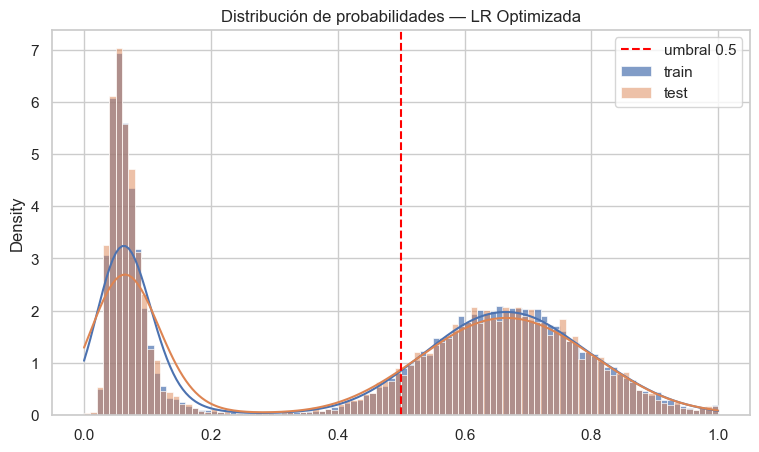

In [35]:
y_train_proba_lr = best_lr.predict_proba(X_train)[:, 1]
y_test_proba_lr  = best_lr.predict_proba(X_test)[:, 1]

plt.figure(figsize=(9, 5))
sns.histplot(y_train_proba_lr, bins=100, kde=True, label="train", stat="density", alpha=0.7)
sns.histplot(y_test_proba_lr,  bins=100, kde=True, label="test",  stat="density", alpha=0.5)
plt.axvline(0.5, color="red", linestyle="--", label="umbral 0.5")
plt.legend()
plt.title("Distribución de probabilidades — LR Optimizada")
plt.show()

In [36]:
threshold_lr = 0.5  # ajustá según el histograma

y_train_pred_lr = (y_train_proba_lr >= threshold_lr).astype(int)
y_test_pred_lr  = (y_test_proba_lr  >= threshold_lr).astype(int)

print("Train")
print(classification_report(y_train, y_train_pred_lr))
print("------------------------------------------------")
print("Test")
print(classification_report(y_test, y_test_pred_lr))

Train
              precision    recall  f1-score   support

           0       0.93      0.60      0.73     25297
           1       0.57      0.92      0.70     14583

    accuracy                           0.72     39880
   macro avg       0.75      0.76      0.72     39880
weighted avg       0.80      0.72      0.72     39880

------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      6324
           1       0.58      0.91      0.71      3646

    accuracy                           0.73      9970
   macro avg       0.75      0.77      0.73      9970
weighted avg       0.80      0.73      0.73      9970



### 5.2 Random Forest optimizado

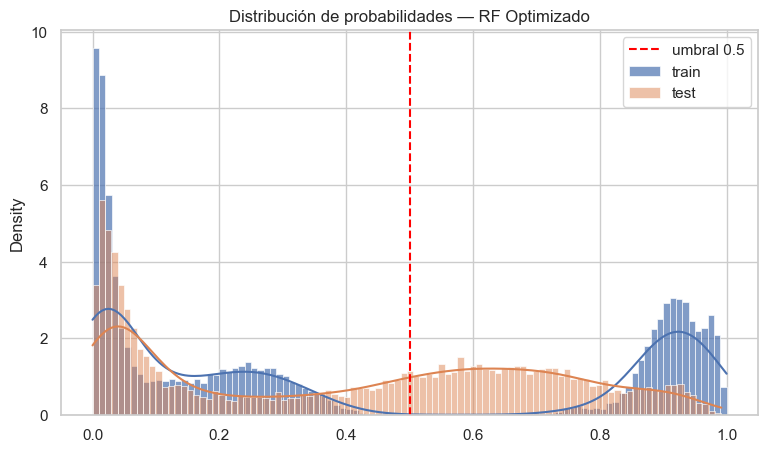

In [37]:
y_train_proba_rf = best_rf.predict_proba(X_train)[:, 1]
y_test_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(9, 5))
sns.histplot(y_train_proba_rf, bins=100, kde=True, label="train", stat="density", alpha=0.7)
sns.histplot(y_test_proba_rf,  bins=100, kde=True, label="test",  stat="density", alpha=0.5)
plt.axvline(0.5, color="red", linestyle="--", label="umbral 0.5")
plt.legend()
plt.title("Distribución de probabilidades — RF Optimizado")
plt.show()

In [38]:
threshold_rf = 0.5  # ajustá según el histograma

y_train_pred_rf = (y_train_proba_rf >= threshold_rf).astype(int)
y_test_pred_rf  = (y_test_proba_rf  >= threshold_rf).astype(int)

print("Train")
print(classification_report(y_train, y_train_pred_rf))
print("------------------------------------------------")
print("Test")
print(classification_report(y_test, y_test_pred_rf))

Train
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25297
           1       1.00      1.00      1.00     14583

    accuracy                           1.00     39880
   macro avg       1.00      1.00      1.00     39880
weighted avg       1.00      1.00      1.00     39880

------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      6324
           1       0.68      0.83      0.75      3646

    accuracy                           0.80      9970
   macro avg       0.79      0.80      0.79      9970
weighted avg       0.81      0.80      0.80      9970



### 5.3 XGBoost optimizado

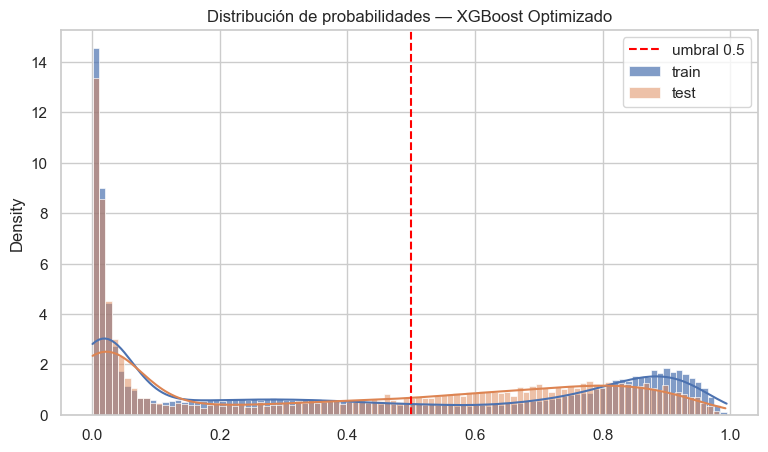

In [39]:
y_train_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]
y_test_proba_xgb  = best_xgb.predict_proba(X_test)[:, 1]

plt.figure(figsize=(9, 5))
sns.histplot(y_train_proba_xgb, bins=100, kde=True, label="train", stat="density", alpha=0.7)
sns.histplot(y_test_proba_xgb,  bins=100, kde=True, label="test",  stat="density", alpha=0.5)
plt.axvline(0.5, color="red", linestyle="--", label="umbral 0.5")
plt.legend()
plt.title("Distribución de probabilidades — XGBoost Optimizado")
plt.show()

In [40]:
threshold_xgb = 0.5  # ajustá según el histograma

y_train_pred_xgb = (y_train_proba_xgb >= threshold_xgb).astype(int)
y_test_pred_xgb  = (y_test_proba_xgb  >= threshold_xgb).astype(int)

print("Train")
print(classification_report(y_train, y_train_pred_xgb))
print("------------------------------------------------")
print("Test")
print(classification_report(y_test, y_test_pred_xgb))

Train
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     25297
           1       0.87      0.99      0.93     14583

    accuracy                           0.94     39880
   macro avg       0.93      0.95      0.94     39880
weighted avg       0.95      0.94      0.94     39880

------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      6324
           1       0.67      0.83      0.74      3646

    accuracy                           0.78      9970
   macro avg       0.77      0.79      0.78      9970
weighted avg       0.80      0.78      0.79      9970



---
## 6. Importancia de atributos y SHAP

Inspeccionamos el modelo ganador (ajustá el nombre si cambia).

<Figure size 1000x800 with 0 Axes>

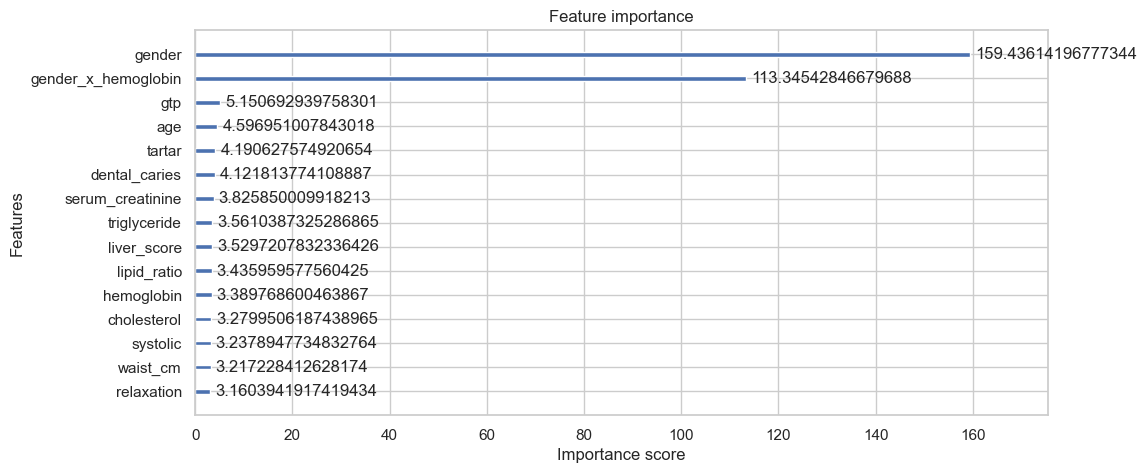

In [41]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(best_xgb, max_num_features=15, importance_type="gain")
plt.show()

In [ ]:
%pip install shap

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ---------------------------------------- 0.0/59.7 kB ? eta -:--:--
     -------------------------- ----------- 41.0/59.7 kB 991.0 kB/s eta 0:00:01
     ---------------------------------------- 59.7/59.7 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/499.9 kB ? eta -:--:--
   --------- ------------------------------ 112.6/499.9 kB 3.3 MB/s eta 0:00:01
   ----------- ---------------------------- 143.4/499.9 kB 2.1 MB/s eta 0:00:01
   ------------------ --------------------- 235.5/499.9 kB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 450.6/499.9 kB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 499.9/499.9 kB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.2/15.6 MB 5.0 MB/s eta 0:00:04
   - -------------------------------------- 0.4/15.6 MB 5.1 MB/s eta 0:00:03


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.0.2 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.0.2 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.3 which is incompatible.
streamlit 1.32.0 requires tenacity<9,>=8.1.0, but you have tenacity 9.1.4 which is incompatible.


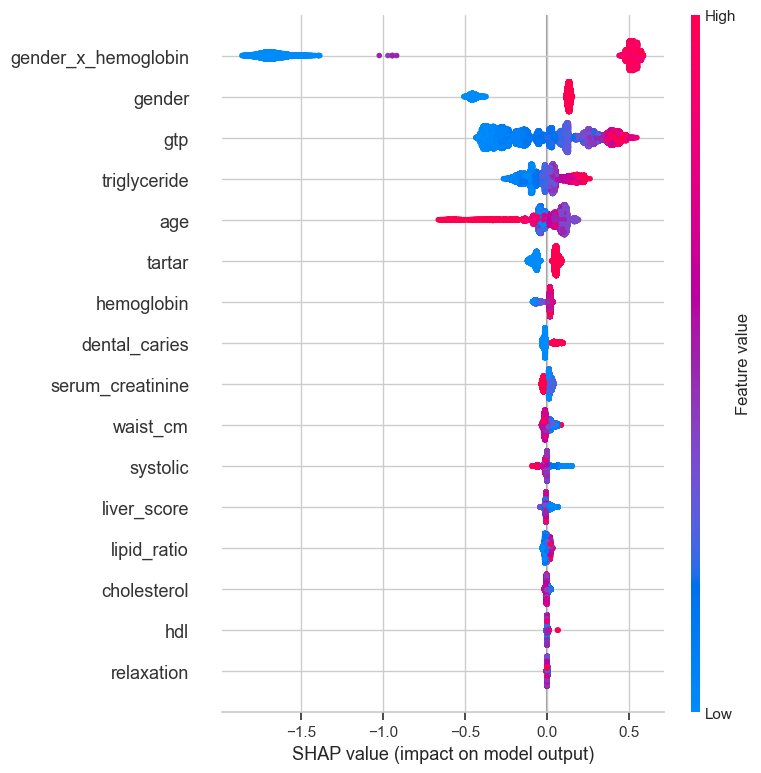

In [ ]:
import shap

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

## 6. Comparación baseline vs. optimizado

In [42]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

comparacion = {
    "LR  Baseline":   (modelos_base[0][1], 0.5),
    "LR  Optimizado": (best_lr,  threshold_lr),
    "RF  Baseline":   (modelos_base[1][1], 0.5),
    "RF  Optimizado": (best_rf,  threshold_rf),
    "XGB Baseline":   (modelos_base[2][1], 0.5),
    "XGB Optimizado": (best_xgb, threshold_xgb),
}

print("=" * 75)
print(f"{'Modelo':<22} {'F1':>8} {'Accuracy':>10} {'Recall':>8} {'Precision':>10}")
print("=" * 75)

for i, (nombre, (modelo, thresh)) in enumerate(comparacion.items()):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)

    f1        = f1_score(y_test, y_pred, pos_label=1)
    accuracy  = accuracy_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred, pos_label=1)
    precision = precision_score(y_test, y_pred, pos_label=1)

    if i % 2 == 0:
        print("-" * 75)
    print(f"{nombre:<22} {f1:>8.4f} {accuracy:>10.4f} {recall:>8.4f} {precision:>10.4f}")

print("=" * 75)


Modelo                       F1   Accuracy   Recall  Precision
---------------------------------------------------------------------------
LR  Baseline             0.7087     0.7266   0.9095     0.5805
LR  Optimizado           0.7085     0.7268   0.9078     0.5809
---------------------------------------------------------------------------
RF  Baseline             0.7506     0.7962   0.8385     0.6793
RF  Optimizado           0.7494     0.7960   0.8343     0.6802
---------------------------------------------------------------------------
XGB Baseline             0.7191     0.7612   0.8357     0.6310
XGB Optimizado           0.7372     0.7849   0.8250     0.6662


La ganancia de la optimización fue marginal en LR y RF, lo que indica que el límite está en los datos y el feature engineering, no en los hiperparámetros. XGBoost fue el único que mostró mejora real (+0.018 F1). El modelo final seleccionado es RF Baseline por tener el mayor F1 (0.750) con buena precision-recall balance.

## 7. Selección y guardado del modelo final

Seleccionamos el modelo con mayor **F1-score** en test y lo guardamos en `models/`.

In [43]:
# Seleccionar el mejor modelo manualmente o por métrica
todos_resultados = [
    ("LR  Baseline",   modelos_base[0][1], 0.5),
    ("LR  Optimizado", best_lr,            threshold_lr),
    ("RF  Baseline",   modelos_base[1][1], 0.5),
    ("RF  Optimizado", best_rf,            threshold_rf),
    ("XGB Baseline",   modelos_base[2][1], 0.5),
    ("XGB Optimizado", best_xgb,           threshold_xgb),
]
mejor_nombre, mejor_modelo, mejor_thresh = max(
    todos_resultados,
    key=lambda x: f1_score(y_test, (x[1].predict_proba(X_test)[:,1] >= x[2]).astype(int), pos_label=1)
)

print(f"Modelo seleccionado: {mejor_nombre}")
print(f"  F1        : {f1_score(y_test, (mejor_modelo.predict_proba(X_test)[:,1] >= mejor_thresh).astype(int), pos_label=1):.4f}")
print(f"  Threshold : {mejor_thresh}")

MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

modelo_path   = os.path.join(MODELS_DIR, "modelo_final.joblib")
features_path = os.path.join(MODELS_DIR, "feature_names.joblib")

joblib.dump(mejor_modelo, modelo_path)
joblib.dump(list(X_train.columns), features_path)

print(f"Modelo guardado en:  {modelo_path}")
print(f"Features guardados en: {features_path}")

Modelo seleccionado: RF  Baseline
  F1        : 0.7506
  Threshold : 0.5
Modelo guardado en:  c:\Users\anshu\Desktop\TP2-Diplomatura\models\modelo_final.joblib
Features guardados en: c:\Users\anshu\Desktop\TP2-Diplomatura\models\feature_names.joblib
